In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

ruta = r"C:\Users\GzzB_\Documents\Kike\Portafolio-Data-Analytics\casoDeNegocio_Ventas\dataset_Original\Videogame Sales.csv"
df = pd.read_csv(ruta)

print(df.head())

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  



Promedio de ventas globales: 0.54 millones
Total de ventas globales: 8820.36 millones

Top 10 juegos más vendidos:
                        Name Platform  Year         Genre  Global_Sales
0                 Wii Sports      Wii  2006        Sports         82.74
1          Super Mario Bros.      NES  1985      Platform         40.24
2             Mario Kart Wii      Wii  2008        Racing         35.82
3          Wii Sports Resort      Wii  2009        Sports         33.00
4   Pokemon Red/Pokemon Blue       GB  1996  Role-Playing         31.37
5                     Tetris       GB  1989        Puzzle         30.26
6      New Super Mario Bros.       DS  2006      Platform         30.01
7                   Wii Play      Wii  2006          Misc         29.02
8  New Super Mario Bros. Wii      Wii  2009      Platform         28.62
9                  Duck Hunt      NES  1984       Shooter         28.31


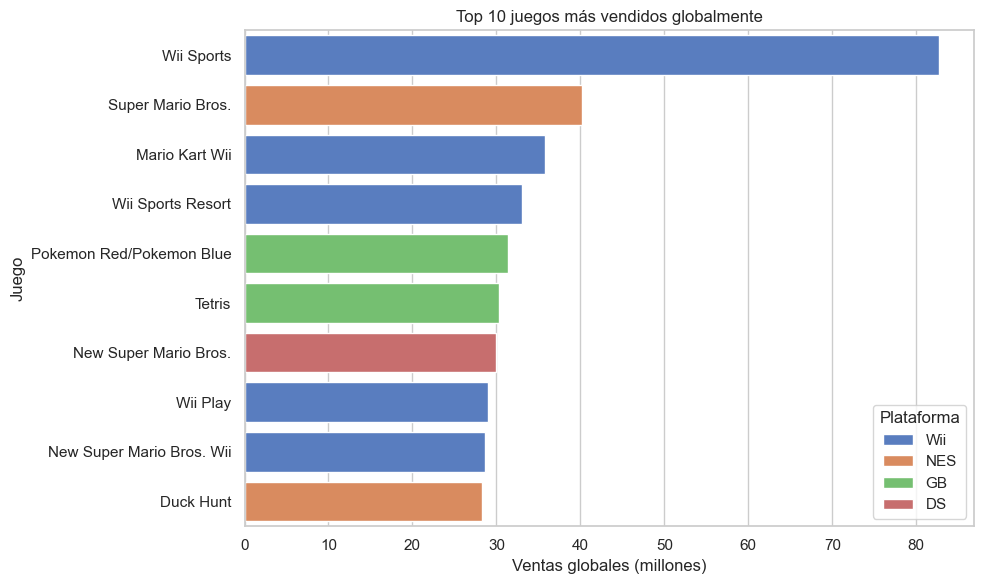

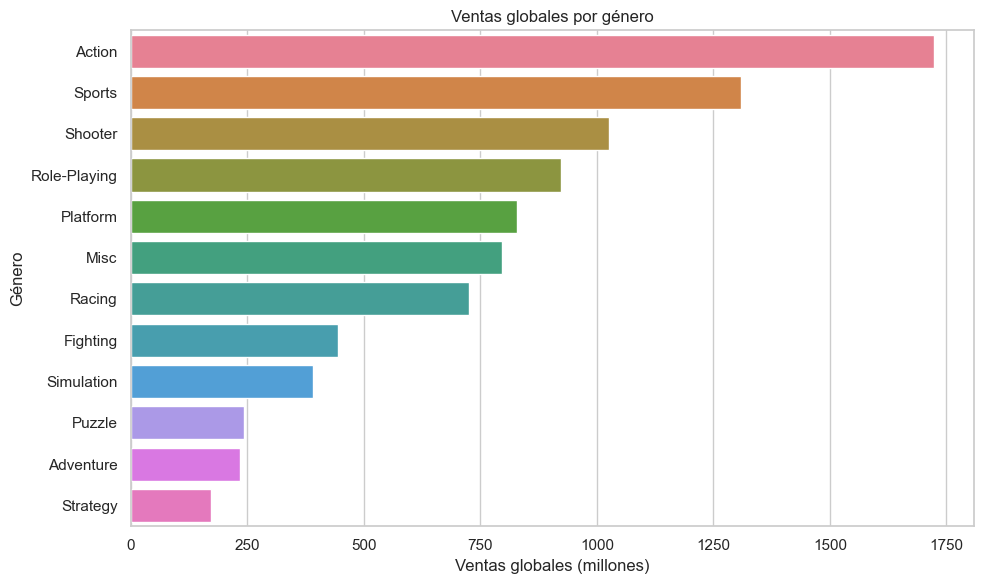

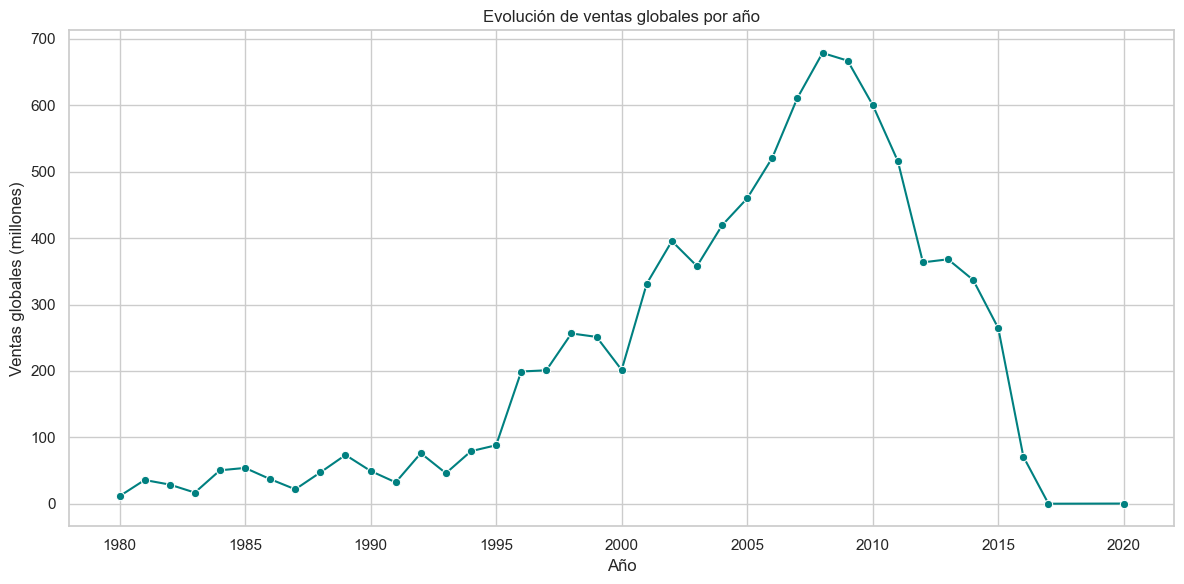


El género con más ventas globales es: Action
El año con más ventas globales fue: 2008


In [17]:
df = df.dropna(subset=["Year", "Genre", "Global_Sales"])
df["Year"] = df["Year"].astype(int)

promedio_global = np.mean(df["Global_Sales"])
total_global = np.sum(df["Global_Sales"])
print(f"\nPromedio de ventas globales: {promedio_global:.2f} millones")
print(f"Total de ventas globales: {total_global:.2f} millones")


top10 = df.sort_values(by="Global_Sales", ascending=False).head(10)
print("\nTop 10 juegos más vendidos:")
print(top10[["Name", "Platform", "Year", "Genre", "Global_Sales"]])

# Top 10 global

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x="Global_Sales", y="Name", hue="Platform", dodge=False)
plt.title("Top 10 juegos más vendidos globalmente")
plt.xlabel("Ventas globales (millones)")
plt.ylabel("Juego")
plt.legend(title="Plataforma")
plt.tight_layout()
plt.show()

# Ventas por género

ventas_por_genero = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=ventas_por_genero.values, y=ventas_por_genero.index, hue=ventas_por_genero.index, legend=False)
plt.title("Ventas globales por género")
plt.xlabel("Ventas globales (millones)")
plt.ylabel("Género")
plt.tight_layout()
plt.show()

# Evolución temporal

ventas_por_año = df.groupby("Year")["Global_Sales"].sum()
plt.figure(figsize=(12, 6))
sns.lineplot(x=ventas_por_año.index, y=ventas_por_año.values, marker="o", color="teal")
plt.title("Evolución de ventas globales por año")
plt.xlabel("Año")
plt.ylabel("Ventas globales (millones)")
plt.tight_layout()
plt.show()

# Insights 
mayor_genero = ventas_por_genero.idxmax()
mayor_año = ventas_por_año.idxmax()
print(f"\nEl género con más ventas globales es: {mayor_genero}")
print(f"El año con más ventas globales fue: {mayor_año}")
